# Task 2: Predictive Modeling Using Machine Learning

## Customer Purchase Prediction

This project demonstrates supervised machine learning by predicting whether a customer is likely to purchase a product based on age and estimated salary.

## Objectives

- Prepare a dataset for machine learning
- Split data into training and testing sets
- Train Logistic Regression, Decision Tree, and Random Forest models
- Compare model accuracy
- Evaluate the best model using a confusion matrix and ROC curve
- Make a sample customer prediction

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.2 MB 13.9 MB/s eta 0:00:01
   ----------------- ---------------------- 3.7/8.2 MB 8.8 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.2 MB 6.8 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.2 MB 6.3 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.2 MB 5.6 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.2 MB 5.3 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.2 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 4.8 MB/s  0:00:01
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/36.6 MB ? eta -:--:--
    --------------------------------------- 0.8/36.6 MB 2.0 MB/s eta 0:00:18
   - -------------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

print('Libraries imported successfully!')

Libraries imported successfully!


## 1. Create the Dataset

In [3]:
np.random.seed(42)

n = 500
age = np.random.randint(18, 61, n)
salary = np.random.randint(20000, 150001, n)

# Purchase rule with a small amount of noise to make the problem realistic
score = 0.06 * age + 0.000018 * salary + np.random.normal(0, 0.7, n)
purchase = (score > 3.2).astype(int)

data = pd.DataFrame({
    'Age': age,
    'EstimatedSalary': salary,
    'Purchased': purchase
})

data.head()

,Age,EstimatedSalary,Purchased
0,56,57841,1
1,46,90640,1
2,32,85510,1
3,60,54911,1
4,25,79031,1


## 2. Explore and Check the Data

In [4]:
print('Dataset Shape:', data.shape)
print('\nMissing Values:')
print(data.isnull().sum())
print('\nDataset Information:')
data.info()
print('\nSummary Statistics:')
display(data.describe())

Dataset Shape: (500, 3)

Missing Values:
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              500 non-null    int32
 1   EstimatedSalary  500 non-null    int32
 2   Purchased        500 non-null    int64
dtypes: int32(2), int64(1)
memory usage: 7.9 KB

Summary Statistics:


,Age,EstimatedSalary,Purchased
count,500.000000,500.000000,500.000000
mean,39.506000,82190.970000,0.674000
std,12.368505,37949.790228,0.469217
min,18.000000,20055.000000,0.000000
25%,29.000000,48225.250000,0.000000
50%,41.000000,78079.000000,1.000000
75%,50.000000,114117.000000,1.000000
max,60.000000,149695.000000,1.000000


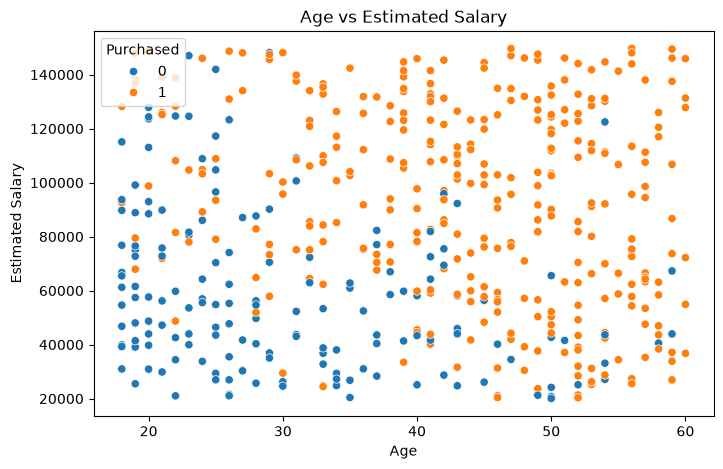

In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='Age', y='EstimatedSalary', hue='Purchased')
plt.title('Age vs Estimated Salary')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.show()

## 3. Prepare Data for Machine Learning

In [6]:
X = data[['Age', 'EstimatedSalary']]
y = data['Purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Training data:', X_train.shape)
print('Testing data:', X_test.shape)

Training data: (400, 2)
Testing data: (100, 2)


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Feature scaling completed.')

Feature scaling completed.


## 4. Train Machine Learning Models

In [8]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
trained_models = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    results[name] = accuracy
    trained_models[name] = model
    print(f'{name}: {accuracy * 100:.2f}%')

Logistic Regression: 88.00%
Decision Tree: 76.00%
Random Forest: 87.00%


## 5. Compare Model Performance

In [9]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

,Model,Accuracy
0,Logistic Regression,0.88
1,Random Forest,0.87
2,Decision Tree,0.76


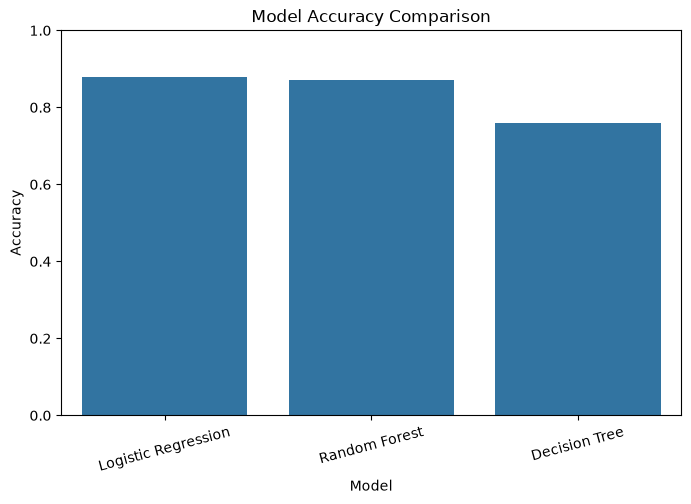

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='Model', y='Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.show()

## 6. Confusion Matrix for the Best Model

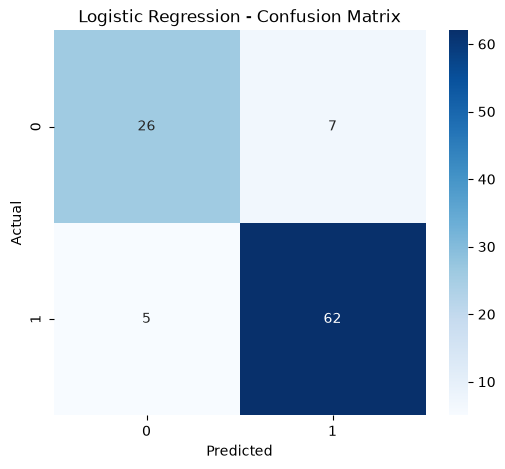

Best Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.79      0.81        33
           1       0.90      0.93      0.91        67

    accuracy                           0.88       100
   macro avg       0.87      0.86      0.86       100
weighted avg       0.88      0.88      0.88       100



In [11]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

if best_model_name == 'Logistic Regression':
    best_predictions = best_model.predict(X_test_scaled)
else:
    best_predictions = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'{best_model_name} - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Best Model:', best_model_name)
print('\nClassification Report:')
print(classification_report(y_test, best_predictions))

## 7. ROC Curve

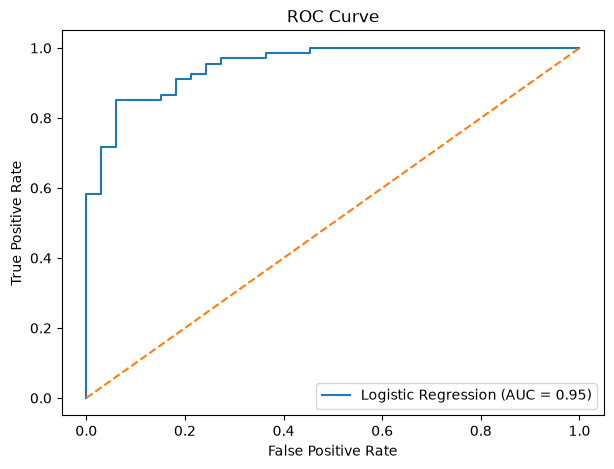

ROC-AUC Score: 0.951


In [12]:
if best_model_name == 'Logistic Regression':
    probabilities = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    probabilities = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, probabilities)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print(f'ROC-AUC Score: {roc_auc:.3f}')

## 8. Make a New Prediction

In [13]:
new_customer = pd.DataFrame({
    'Age': [40],
    'EstimatedSalary': [80000]
})

if best_model_name == 'Logistic Regression':
    prediction = best_model.predict(scaler.transform(new_customer))
else:
    prediction = best_model.predict(new_customer)

if prediction[0] == 1:
    print('Prediction: Customer is likely to purchase.')
else:
    print('Prediction: Customer is unlikely to purchase.')

Prediction: Customer is likely to purchase.


## Conclusion

The project successfully applied supervised machine learning to predict customer purchase behavior. Logistic Regression, Decision Tree, and Random Forest were trained and evaluated. Accuracy comparison, a confusion matrix, and an ROC curve were used to assess model performance. The best-performing model can be used to make predictions for new customers.